In [3]:
# 必要なモジュールをインポート
import os
import glob
import cv2

# 指定された動画ファイルをフレーム化
video_path = r"C:\Users\MSAD\github\nnspike\storage\20251003\videos\20250909173756_picamera.avi"
output_dir = r"C:\Users\MSAD\github\nnspike\storage\20251003\frames\20250909173756_picamera"

# 出力ディレクトリが存在しない場合は作成
os.makedirs(output_dir, exist_ok=True)

print(f"動画ファイル: {video_path}")
print(f"出力ディレクトリ: {output_dir}")

# 動画ファイルの存在確認
if os.path.exists(video_path):
    print("✓ 動画ファイルが見つかりました")
    
    # OpenCVで動画を読み込み
    cap = cv2.VideoCapture(video_path)
    
    if cap.isOpened():
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        print(f"総フレーム数: {frame_count}")
        print(f"FPS: {fps}")
        
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # フレームを保存
            frame_filename = f"frame_{frame_idx:06d}.jpg"
            frame_path = os.path.join(output_dir, frame_filename)
            cv2.imwrite(frame_path, frame)
            
            # 進捗表示（100フレームごと）
            if frame_idx % 100 == 0:
                print(f"フレーム {frame_idx} / {frame_count} 処理中...")
            
            frame_idx += 1
        
        cap.release()
        print(f"✓ フレーム抽出が完了しました")
        print(f"✓ 抽出されたフレーム数: {frame_idx} 枚")
        
    else:
        print("✗ 動画ファイルを開けませんでした")
else:
    print("✗ 動画ファイルが見つかりません")

動画ファイル: C:\Users\MSAD\github\nnspike\storage\20251003\videos\20250909173756_picamera.avi
出力ディレクトリ: C:\Users\MSAD\github\nnspike\storage\20251003\frames\20250909173756_picamera
✓ 動画ファイルが見つかりました
総フレーム数: 1626
FPS: 30.0
フレーム 0 / 1626 処理中...
フレーム 100 / 1626 処理中...
フレーム 200 / 1626 処理中...
フレーム 300 / 1626 処理中...
フレーム 400 / 1626 処理中...
フレーム 500 / 1626 処理中...
フレーム 600 / 1626 処理中...
フレーム 700 / 1626 処理中...
フレーム 800 / 1626 処理中...
フレーム 900 / 1626 処理中...
フレーム 1000 / 1626 処理中...
フレーム 1100 / 1626 処理中...
フレーム 1200 / 1626 処理中...
フレーム 1300 / 1626 処理中...
フレーム 1400 / 1626 処理中...
フレーム 1500 / 1626 処理中...
フレーム 1600 / 1626 処理中...
✓ フレーム抽出が完了しました
✓ 抽出されたフレーム数: 1626 枚


抽出されたフレームファイル数: 1626
最初のフレーム: frame_000000.jpg
最後のフレーム: frame_001625.jpg


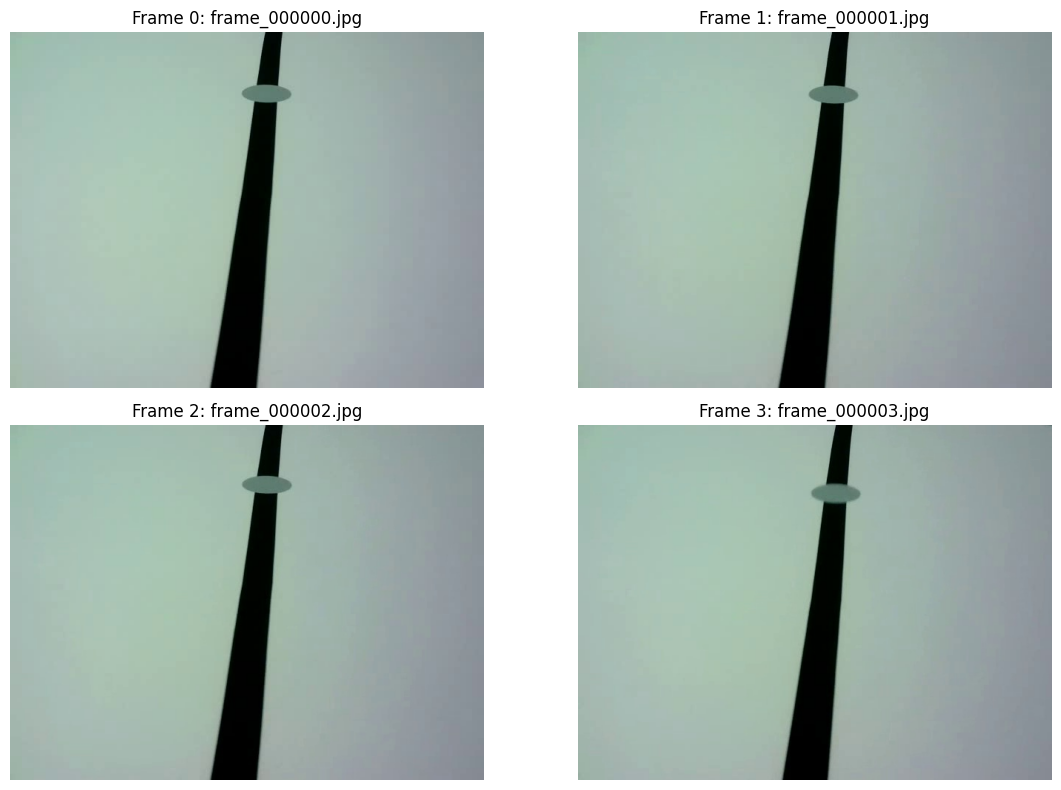


フレームファイルは以下のディレクトリに保存されました:
C:\Users\MSAD\github\nnspike\storage\20251003\frames\20250909173756_picamera


In [4]:
# 抽出結果の確認
import matplotlib.pyplot as plt

# 抽出されたフレームファイルを取得
frame_files = sorted(glob.glob(os.path.join(output_dir, "*.jpg")))
print(f"抽出されたフレームファイル数: {len(frame_files)}")

# 最初の数フレームを表示
if len(frame_files) > 0:
    print(f"最初のフレーム: {os.path.basename(frame_files[0])}")
    print(f"最後のフレーム: {os.path.basename(frame_files[-1])}")
    
    # 最初の4フレームを表示
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i in range(min(4, len(frame_files))):
        frame = cv2.imread(frame_files[i])
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Frame {i}: {os.path.basename(frame_files[i])}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nフレームファイルは以下のディレクトリに保存されました:")
    print(f"{output_dir}")
else:
    print("フレームファイルが見つかりません")

In [2]:
import sys
sys.path.append('..')

import os
import re
import glob
import pandas as pd

from nnspike.utils import extract_video_frames
from nnspike.data import create_label_dataframe, sort_by_frames_number, label_dataset_by_opencv, label_dataset_by_model, augment_dataset, set_spike_status
from nnspike.constants import  ROI_CNN

course = "right" # "right" or "left"

ImportError: cannot import name 'is_x320_on_blue_target' from 'nnspike.utils.control' (c:\Users\MSAD\github\nnspike\nnspike\utils\control.py)

## Extract Frames from Videos

In [12]:
def get_all_avi_files(directory_path="C:/Users/MSAD/github/nnspike/storage/20250910/videos/", filter_timestamp=None):
    """
    Get all AVI files from the specified directory with their timestamps.
    
    Args:
        directory_path (str): Path to the directory containing AVI files
        filter_timestamp (str, optional): If set, only return files matching this timestamp pattern (supports wildcards with *)
    
    Returns:
        list: List of tuples containing (file_path, timestamp)
    """
    import os
    import glob
    import re
    import fnmatch

    # Use glob to find all .avi files in the directory
    avi_files = glob.glob(os.path.join(directory_path, "*.avi"))
    avi_files = [path.replace("\\", "/") for path in avi_files]
    
    # Sort the files for consistent ordering
    avi_files.sort()
    
    # Extract timestamps and create tuples
    result = []
    for avi_file in avi_files:
        # Extract filename without extension
        filename = os.path.basename(avi_file)
        filename_no_ext = os.path.splitext(filename)[0]
        
        # Extract timestamp from filename (assuming format: timestamp_picamera.avi)
        # This will extract the part before '_picamera'
        timestamp_match = re.match(r'^(\d{14})_.*', filename_no_ext)
        if timestamp_match:
            timestamp = timestamp_match.group(1)
        else:
            # If timestamp pattern not found, use the full filename without extension
            timestamp = filename_no_ext

        # If filter_timestamp is set, only include matching files using pattern matching
        if filter_timestamp is None or fnmatch.fnmatch(timestamp, filter_timestamp):
            result.append((avi_file, timestamp))
    
    return result

def extract_frames_from_avi_files(avi_files_with_timestamps, base_output_dir="C:/Users/MSAD/github/nnspike/storage/20250910/frames/"):
    """
    Extract frames from all AVI files and save them to folders named by timestamp.
    
    Args:
        avi_files_with_timestamps (list): List of tuples containing (file_path, timestamp)
        base_output_dir (str): Base directory where frame folders will be created
    
    Returns:
        list: List of tuples containing (output_directory, timestamp)
    """
    output_directories_with_timestamps = []
    
    for avi_file, timestamp in avi_files_with_timestamps:
        # Create output directory path
        output_dir = os.path.join(base_output_dir, timestamp)
        
        # Create directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Add trailing slash for extract_video_frames function
        output_dir_with_slash = output_dir + "/"
        
        filename = os.path.basename(avi_file)
        print(f"Extracting frames from {filename} to {output_dir_with_slash}")
        
        try:
            # Extract frames using the nnspike utility function
            extract_video_frames(avi_file, output_dir_with_slash)
            print(f"✓ Successfully extracted frames to {timestamp}/")
            # Add successful output directory and timestamp to the list
            output_directories_with_timestamps.append((output_dir, timestamp))
        except Exception as e:
            print(f"✗ Error extracting frames from {filename}: {str(e)}")
    
    return output_directories_with_timestamps



In [13]:
# Get all AVI files with their timestamps
avi_files_with_timestamps = get_all_avi_files(directory_path="C:/Users/MSAD/github/nnspike/storage/20250910/videos/")
avi_files_with_timestamps

[('C:/Users/MSAD/github/nnspike/storage/20250910/videos/20250910112636_picamera.avi',
  '20250910112636'),
 ('C:/Users/MSAD/github/nnspike/storage/20250910/videos/20250910120011_picamera.avi',
  '20250910120011')]

In [14]:
    # Extract frames from all AVI files
if avi_files_with_timestamps:
    print("\nStarting frame extraction...")
    output_dirs_with_timestamps = extract_frames_from_avi_files(avi_files_with_timestamps, base_output_dir="C:/Users/MSAD/github/nnspike/storage/20250910/frames/")
    print("\nFrame extraction completed!")
    print(f"Successfully created {len(output_dirs_with_timestamps)} output directories:")
    for output_dir, timestamp in output_dirs_with_timestamps:
        print(f"  - {output_dir} (timestamp: {timestamp})")
else:
    print("No AVI files found to process.")
    output_dirs_with_timestamps = []
    
output_dirs_with_timestamps


Starting frame extraction...
Extracting frames from 20250910112636_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910112636/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\20250910\frames\20250910112636
✓ Successfully extracted frames to 20250910112636/
Extracting frames from 20250910120011_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910120011/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\20250910\frames\20250910112636
✓ Successfully extracted frames to 20250910112636/
Extracting frames from 20250910120011_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910120011/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\20250910\frames\20250910120011
✓ Successfully extracted frames to 20250910120011/

Frame extraction completed!
Successfully created 2 output directories:
  - C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910112636 (timestamp: 20250910112636)
  - C:/Us

[('C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910112636',
  '20250910112636'),
 ('C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910120011',
  '20250910120011')]

In [15]:
import os
for output_dir, timestamp in output_dirs_with_timestamps:
    print(f"Output directory: {output_dir} (timestamp: {timestamp})")
    
    course = "right"
    label_df = create_label_dataframe(output_dir +"/*", course)
    if label_df is None or label_df.empty:
        print(f"Warning: label_df is empty for timestamp {timestamp}, skipping.")
        continue
    print("label_df type:", type(label_df))
    print("label_df head:", getattr(label_df, "head", lambda: "no head")())
    label_df = sort_by_frames_number(label_df)
    label_df = label_dataset_by_opencv(label_df, ROI_CNN, 80)
    
    sensor_path = f"C:/Users/MSAD/github/nnspike/storage/20250910/sensor_data/{timestamp}_sensor_log.csv"
    if not os.path.exists(sensor_path):
        print(f"Warning: Sensor log not found for timestamp {timestamp}, skipping.")
        continue
    
    status_df = pd.read_csv(sensor_path)
    df = set_spike_status(label_df, status_df)
    
    # Export to a csv file
    df.to_csv(f"C:/Users/MSAD/github/nnspike/storage/20250910/labels/{timestamp}_label.csv", index=False)

Output directory: C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910112636 (timestamp: 20250910112636)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

Processing: 100%|██████████| 376/376 [00:09<00:00, 38.00it/s]



Output directory: C:/Users/MSAD/github/nnspike/storage/20250910/frames/20250910120011 (timestamp: 20250910120011)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20250910/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

Processing: 100%|██████████| 1239/1239 [00:31<00:00, 39.70it/s]

